# Case Study 3: Conjugate Gradient Algorithm
Name: Marc Lane

Student ID: 21364269

Email: lanem2@tcd.ie

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from CG_Algorithm_function import conjugate_gradient
from get_covariance_matrix import get_covariance_matrix

## Question 1
I implemented the CG algorithm section 6.7 of Saad’s textbook in the .py file "CG_Algorithm_function.py". It takes the matrix $A$, the right-hand side vector $b$, the tolerance ($\texttt{tol}$), and the maximum number of iterations ($\texttt{max\_iters}$) as arguments.

## Question 2
I reimplemented the get_covariance_matrix.m file on Blackboard as a .py file. 

For N = 512
CG converged in 407 iterations
Final relative residual = 3.66e-10

For N = 1024
CG converged in 627 iterations
Final relative residual = 2.91e-10

For N = 2048
CG converged in 850 iterations
Final relative residual = 2.08e-10



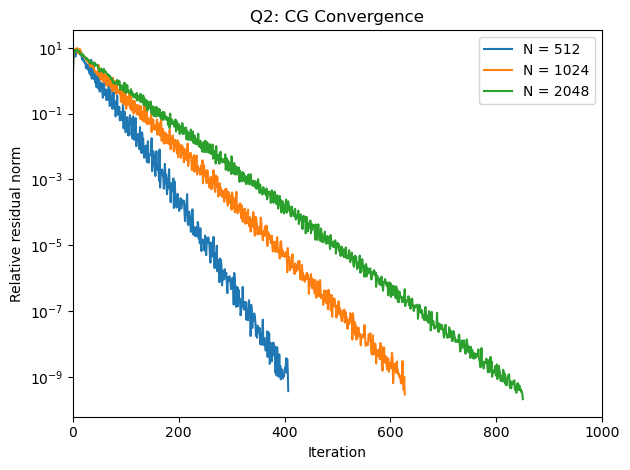

In [2]:
# Parameters
tau = 20
noise = 0.005
tol = 1e-8
sizes = [512, 1024, 2048] # matrix sizes to test

results = {}
 
for N in sizes:
    print(f"For N = {N}")
    A, b = get_covariance_matrix(N, tau, noise)
    x, iters, res_history = conjugate_gradient(A, b, tol=tol)
    results[N] = {"x": x, "ters": iters, "res_history": res_history}
    print(f"Final relative residual = {res_history[-1]:.2e}")
    print(f"")

# Plotting relative residual norm vs iteration for each size
plt.figure()
for N in sizes:
    res = results[N]["res_history"]
    plt.semilogy(range(len(res)), res, label=f"N = {N}")
plt.xlabel("Iteration")
plt.ylabel("Relative residual norm")
plt.title("Q2: CG Convergence")
plt.xlim(0,1000)
plt.legend()
plt.tight_layout()
plt.savefig("Q2_convergence.png", dpi=300)
plt.show()

## Question 3

In [3]:
tau = 269
tol = 1e-8
N = 1024

# Varying noise parameter
noise_values = [0.5, 5e-2, 5e-3, 5e-4, 5e-5, 5e-6, 5e-7, 5e-8]

for noise in noise_values:
    A, b = get_covariance_matrix(N, tau, noise)
    cond = np.linalg.cond(A) # Computing the condition number of A
    print(f"For Noise = {noise:.1e}, Condition number = {cond:.2e}")
    x, iters, res_history = conjugate_gradient(A, b, tol=tol)
    print("")

For Noise = 5.0e-01, Condition number = 9.92e+02
CG converged in 35 iterations

For Noise = 5.0e-02, Condition number = 9.91e+03
CG converged in 70 iterations

For Noise = 5.0e-03, Condition number = 9.91e+04
CG converged in 166 iterations

For Noise = 5.0e-04, Condition number = 9.91e+05
CG converged in 439 iterations

For Noise = 5.0e-05, Condition number = 9.91e+06
CG did not converge: reached max iterations of (1000)

For Noise = 5.0e-06, Condition number = 9.87e+07
CG did not converge: reached max iterations of (1000)

For Noise = 5.0e-07, Condition number = 9.49e+08
CG did not converge: reached max iterations of (1000)

For Noise = 5.0e-08, Condition number = 6.85e+09
CG did not converge: reached max iterations of (1000)



The output shows that as the noise parameter decreases, the condition number of $A$ increases. This is likely because reducing the noise of $A$ causes the eigenvalue spectrum to spread over a wider interval. CG is a Krylov subspace method that at each iteration constructs a polynomial of increasing degree that must be small at all eigenvalues of A simultaneously. When the eigenvalues are widely spread, higher-degree polynomials are needed to achieve this, requiring more iterations to converge. 

From the results, each order of magnitude decrease in noise increases the condition number by about a factor of 10, and approximately doubles the number of iterations needed.

## Question 4

CG converged in 135 iterations
CG converged in 13 iterations


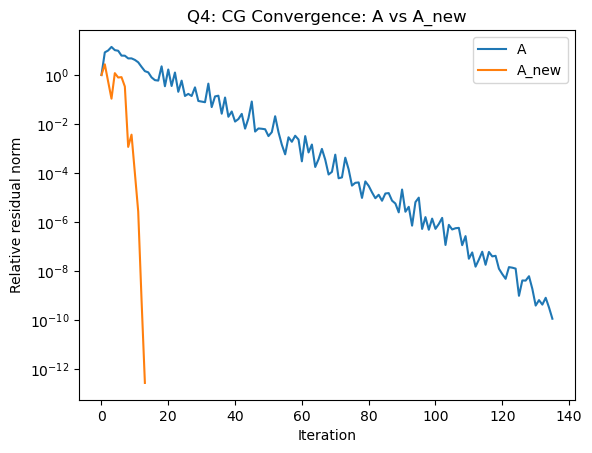

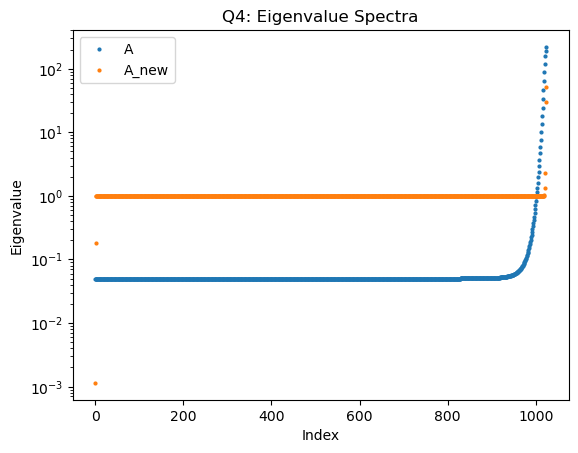

Condition number of A:     4.40e+03
Condition number of A_new: 4.58e+04


In [4]:
# Generate A and b
A, b = get_covariance_matrix(1024, 100, 0.05)

# Run CG on original A
x, iters, res_history = conjugate_gradient(A, b, tol=1e-8)


# Compute A_new (using NumPy)
L = np.linalg.cholesky(A)    # lower triangular
M = L.T                      # upper triangular (computing "M=chol(A)" using NumPy)
M_inv = np.linalg.inv(M)
A_new = M_inv @ A @ M_inv.T

# Run CG on A_new
x_new, iters_new, res_history_new = conjugate_gradient(A_new, b, tol=1e-8)

# Plot convergence
plt.figure()
plt.semilogy(range(len(res_history)), res_history, label="A")
plt.semilogy(range(len(res_history_new)), res_history_new, label="A_new")
plt.xlabel("Iteration")
plt.ylabel("Relative residual norm")
plt.title("Q4: CG Convergence: A vs A_new")
plt.legend()
plt.savefig("Q4_A_vs_Anew.png", dpi=300)
plt.show()

# plot eigenvalue spectra
eigs_A = np.linalg.eigvalsh(A)
eigs_A_new = np.linalg.eigvalsh(A_new)

plt.figure()
plt.plot(eigs_A, 'o', markersize=2, label="A")
plt.plot(eigs_A_new, 'o', markersize=2, label="A_new")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Q4: Eigenvalue Spectra")
plt.yscale('log')
plt.legend()
plt.savefig("Q4_Eigenvalue_spectra.png", dpi=300)
plt.show()

print(f"Condition number of A:     {np.linalg.cond(A):.2e}")
print(f"Condition number of A_new: {np.linalg.cond(A_new):.2e}")

The eigenvalues of $A$ are spread over a wider range, with most clustered near $10^{-1}$ and suddenly increasing exponentially for higher indexes, giving a large condition number. Due to the Cholesky preconditioning, $A_{new}$'s eigenvalues are much more tightly clustered, reducing the condition number significantly. CG constructs polynomials that must be small at all eigenvalues, so a tighter spectrum means a lower-degree polynomial suffices and convergence is faster. For this reason, $A_{new}$ converges much faster than $A$.